### Step-0 :- Set up the right Imports

In [1]:
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")


In [2]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# import ...
# import ...
# import ...

### Step-1: - Load the Datasets needed
1a) -> Perform some basic EDA

In [4]:
# TODO: load breast cancer dataset from sklearn
data = load_breast_cancer()
print(data.keys())
X, y = data['data'], data['target']
assert X.shape == (569, 30); assert y.shape == (569,)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [5]:
# TODO: print feature names and class names
# TODO: print class distribution
print(data['feature_names'])
print(data['target_names'])


['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
['malignant' 'benign']


<Axes: >

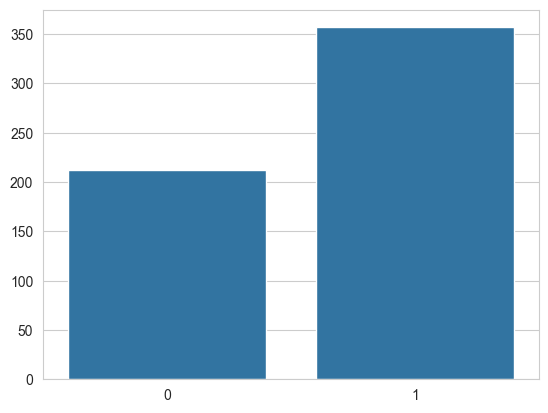

In [43]:
val, counts = np.unique(y, return_counts=True)
sns.barplot(x=val, y=counts)

### Step-2: - Do a basic Train Test Split

In [6]:
# TODO: train/test split, 80/20, stratified, random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, shuffle =True, test_size =0.2)
print(X_train.shape)

assert X_train.shape[0] == 455
assert X_test.shape[0] == 114

(455, 30)


### Step-3: - Transforming Data

In [7]:
# TODO: fit StandardScaler on train, transform both
scaler = StandardScaler(copy=True)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

assert abs(X_train_scaled.mean()) < 1e-10
assert abs(X_train_scaled.std() - 1.0) < 0.05

In [8]:
# TODO: convert to float32 tensors
X_train_t = torch.from_numpy(X_train_scaled).to(torch.float32)
y_train_t = torch.from_numpy(y_train).to(torch.float32)
X_test_t = torch.from_numpy(X_test_scaled).to(torch.float32)
y_test_t = torch.from_numpy(y_test).to(torch.float32)

assert X_train_t.dtype == torch.float32
assert y_train_t.dtype == torch.float32
assert y_train_t.dim() == 1

type(X_train_t), X_train_t.shape, X_train_t.dtype

(torch.Tensor, torch.Size([455, 30]), torch.float32)

In [9]:
# TODO: create TensorDataset and DataLoader, batch_size=32, shuffle=True for train
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_ds = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=True)

batch_X, batch_y = next(iter(train_loader))
assert batch_X.shape == (32, 30)
assert batch_y.shape == (32,)

## Model

In [10]:
# TODO: define MLP — 30 -> 64 -> 32 -> 1, ReLU activations, no sigmoid at end
class BreastCancerMLP(nn.Module):
    def __init__(self, n_input:int=30, n_classes:int=1):
        super(BreastCancerMLP, self).__init__()
        
        self.layer_1 =  nn.Linear(30, 64)
        self.layer_2 =  nn.Linear(64, 32)
        self.layer_3 =  nn.Linear(32, 1)
        
        
    def forward(self, x):
        x = self.layer_1(x)
        x = F.relu(x)
        x = self.layer_2(x)
        x = F.relu(x)
        x = self.layer_3(x)
        return x

model = BreastCancerMLP()
out = model(batch_X)
assert out.shape == (32, 1)

In [11]:
# TODO: count total parameters using model.parameters()
total_params = sum(p.numel() for p in model.parameters())
print(total_params)
# note: parameters() returns only learnable params, buffers() returns non-learnable
assert total_params == 30*64+64 + 64*32+32 + 32*1+1

4097


## Loss

In [ ]:
# TODO: implement manual BCE from logits — sigmoid then -(y*log(p) + (1-y)*log(1-p))
def manual_bce_with_logits(logits, targets):
    targets = targets.float().view_as(logits)
    probs = torch.sigmoid(logits)
    eps = 1e-7
    probs = torch.clamp(probs, eps, 1 - eps)
    return -1*(targets*torch.log(probs) + (1-targets)*torch.log(1-probs)).mean()

logits = model(batch_X).squeeze()
loss_manual = manual_bce_with_logits(logits, batch_y)
loss_torch = nn.BCEWithLogitsLoss()(logits, batch_y)
assert torch.allclose(loss_manual, loss_torch, atol=1e-5)

In [96]:
# TODO: compute pos_weight from class distribution
# note: pos_weight = num_negative / num_positive
num_p, num_n= (y_train_t==1).sum().float(), (y_train_t == 0).sum().float()
print(num_p, num_n)

pos_weight =(num_n / num_p).float()
print(pos_weight.shape)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
assert pos_weight.shape == ()

tensor(290.) tensor(165.)
torch.Size([])


## Optimizer

In [97]:
# TODO: manual SGD — compute loss, backward, update params with lr=0.01
lr = 0.01
loss = criterion(model(batch_X).squeeze(), batch_y)
loss.backward()


In [ ]:
# TODO: loop over model.parameters(), do p.data -= lr * p.grad
with torch.no_grad():
    for param in model.parameters():
        param-=lr*param.grad

# TODO: zero gradients manually
model.zero_grad()

In [ ]:
# TODO: verify manual step matches optim.SGD by comparing param values
model_a = BreastCancerMLP()
model_b = BreastCancerMLP()


# TODO: copy model_a state_dict to model_b
model_b.load_state_dict(model_a.state_dict())

optimizer_b = torch.optim.SGD(model_b.parameters(), lr=0.01)


In [104]:
# TODO: one step on each with same data, assert params match
batch_1 = next(iter(train_loader))

In [114]:
batch_1_x, batch_1_y= batch_1[0], batch_1[1]
type(batch_1_x), type(batch_1_y)

(torch.Tensor, torch.Tensor)

In [116]:
## Training Model A
model_a.train()
optimizer_b.zero_grad()
logits = model_a(batch_1_x)
print(logits.shape, batch_1_y.shape)
loss_val = criterion(logits, batch_1_y.reshape(-1,1))
loss_val.backward()
optimizer_b.step()

torch.Size([32, 1]) torch.Size([32])


In [117]:
## Training Model A
model_b.train()
optimizer_b.zero_grad()
logits = model_b(batch_1_x)
print(logits.shape, batch_1_y.shape)
loss_val = criterion(logits, batch_1_y.reshape(-1,1))
loss_val.backward()
optimizer_b.step()

torch.Size([32, 1]) torch.Size([32])


In [118]:
for pa, pb in zip(model_a.parameters(), model_b.parameters()):
    assert torch.allclose(pa.data, pb.data, atol=1e-6)

AssertionError: 

In [ ]:
# TODO: demonstrate zero_grad bug — run backward twice without zero_grad
# TODO: show that gradients accumulate (grad after 2nd backward ~ 2x grad after 1st)
...

## Training loop

In [ ]:
model = BreastCancerMLP()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()
epochs = 50

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        # TODO: forward, loss, backward, step, zero_grad
        ...

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            # TODO: forward, accumulate loss
            ...

    # TODO: print epoch, train_loss, val_loss every 10 epochs
    ...

## Evaluation

In [ ]:
# TODO: implement accuracy — threshold logits at 0, compare to targets
def binary_accuracy(logits, targets):
    ...

# verify on known values
assert binary_accuracy(torch.tensor([0.5, -0.3, 1.2]), torch.tensor([1.0, 0.0, 1.0])) == 1.0
assert binary_accuracy(torch.tensor([0.5, -0.3, 1.2]), torch.tensor([0.0, 1.0, 0.0])) == 0.0

In [ ]:
# TODO: accumulate accuracy across all test batches
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # TODO: accumulate correct and total
        ...

test_acc = correct / total
assert test_acc > 0.85, f"accuracy too low: {test_acc}"

## Checkpointing

In [ ]:
# TODO: save model state_dict and optimizer state_dict
checkpoint = ...
torch.save(checkpoint, "breast_cancer_mlp.pt")

In [ ]:
# TODO: load checkpoint into a new model
model_loaded = BreastCancerMLP()
checkpoint = torch.load("breast_cancer_mlp.pt")
# TODO: load state_dict
...

# verify predictions match
model.eval()
model_loaded.eval()
with torch.no_grad():
    pred_orig = model(X_test_t)
    pred_loaded = model_loaded(X_test_t)
assert torch.allclose(pred_orig, pred_loaded)

In [ ]:
import os
os.remove("breast_cancer_mlp.pt")